## Repeated measures ANOVA - Movie Scene Ratings

*This script was used to test (post hoc) with one-way repeated measures ANOVAs whether there are significant differences in scene ratings (i.e., mean scene scores) between trait-relevant and trait-irrelevant scenes. The first part assesses ratings from Group 1 (Movies 1 and 2), while the second part assesses ratings from Group 2 (Movies 3 and 4).* 

### 1. Movies 1 & 2

In [151]:
import os
import pandas as pd

print(os.getcwd())
os.chdir(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1")
print(os.getcwd())

C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1
C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1


#### 1.1. Create Dataframe (same way as in script named "Define Trait (ir)-relevant Scenes")

In [153]:
# Folder with CSV files (Pavlovia Output)
data_folder = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1"

# List for collected data 
all_data = []

# Go through all csv files in the folder
for file in os.listdir(data_folder):
    if file.endswith(".csv"):  # make sure that it is a csv file
        file_path = os.path.join(data_folder, file)
        
        # Read csv file
        df = pd.read_csv(file_path)

        # Extract Subject ID from filename
        subject_id = file.split("_")[0]  # First part of the filename is the Subject ID

        # Compute Neuroticism Movie Scene Ratings
        variable_movie_scenes = df["Movie_scenes"].dropna().reset_index(drop=True)
        frustrated_clean = df["Rating_Question_answer_This scene made me feel frustrated"].dropna().reset_index(drop=True)
        dissatisfied_clean = df["Rating_Question_answer_This scene made me feel dissatisfied with myself"].dropna().reset_index(drop=True)
        tense_clean = df["Rating_Question_answer_This scene made me feel tense"].dropna().reset_index(drop=True)
        confident_clean = df["Rating_Question_answer_This scene made me feel confident in myself and my abilities"].dropna().reset_index(drop=True)
        safe_clean = df["Rating_Question_answer_This scene made me feel safe and secure"].dropna().reset_index(drop=True)
        happy_clean = df["Rating_Question_answer_This scene made me feel happy"].dropna().reset_index(drop=True)

        # Combine variables
        complete_movie_scene_ratings = pd.concat(
            [variable_movie_scenes, frustrated_clean, dissatisfied_clean, tense_clean, confident_clean, safe_clean, happy_clean], 
            axis=1
        )

        # Reverse Coding
        reverse_map = {1.0: 5.0, 2.0: 4.0, 3.0: 3.0, 4.0: 2.0, 5.0: 1.0}
        reverse_columns = ["Rating_Question_answer_This scene made me feel confident in myself and my abilities", 
                           "Rating_Question_answer_This scene made me feel safe and secure", 
                           "Rating_Question_answer_This scene made me feel happy"]

        for col in reverse_columns:
            complete_movie_scene_ratings[col + "_reversed"] = complete_movie_scene_ratings[col].replace(reverse_map)

        # Compute sum score
        sum_columns = ["Rating_Question_answer_This scene made me feel frustrated",
                       "Rating_Question_answer_This scene made me feel dissatisfied with myself",
                       "Rating_Question_answer_This scene made me feel tense"] + [col + "_reversed" for col in reverse_columns]

        complete_movie_scene_ratings["Sum_N_score_scene"] = complete_movie_scene_ratings[sum_columns].sum(axis=1)

        # Save individual file with movie scene ratings per subject
        #output_folder = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1\Individual_movie_scene_ratings"
        #file_path_individual_scene_ratings = os.path.join(output_folder, f"complete_movie_scene_ratings_subject_{subject_id}.csv")
        #complete_movie_scene_ratings.to_csv(file_path_individual_scene_ratings, index=False)

        # Compute the neuroticism score from the NEO_FFI_items
        
        map_normally_coded_items = {"SD": 0, "D": 1, "N": 2, "A": 3, "SA": 4} # Items 6, 11, 21, 26, 36, 41, 51, 56
        map_reverse_coded_items = {"SD": 4, "D": 3, "N": 2, "A": 1, "SA": 0} # Items 1, 16, 31, 46

        normally_coded_items = ["Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.6_I often feel inferior to others.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.11_When I'm under a great deal of stress, sometimes I feel like I am going to pieces.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.21_I often feel tense and jittery.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.26_Sometimes I feel completely worthless.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.36_I often get angry at the way people treat me.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.41_Too often when things go wrong, I get discouraged and feel like giving up.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.51_I often feel helpless and want someone else to solve my problems.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.56_At times I have been so ashamed that I just wanted to hide."]
        reverse_coded_items = ["Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.1_I am not a worrier.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.16_I rarely feel lonely or blue.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.31_I rarely feel fearful or anxious.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.46_I am seldom sad or depressed."]

        def recode_value(value, recode_map):
            return recode_map.get(value, None)  # returns none if unknown value

        neuroticism_item_responses = []

        for item in normally_coded_items:
            if item in df.columns:
                value = df[item].iloc[1] if pd.notna(df[item].iloc[1]) and df[item].iloc[1] != "" else df[item].iloc[0]
                recoded_value = recode_value(value, map_normally_coded_items)
                if recoded_value is not None:
                    neuroticism_item_responses.append(recoded_value)
                    
        for item in reverse_coded_items:
            if item in df.columns:
                value = df[item].iloc[1] if pd.notna(df[item].iloc[1]) and df[item].iloc[1] != "" else df[item].iloc[0]
                recoded_value = recode_value(value, map_reverse_coded_items)
                if recoded_value is not None:
                    neuroticism_item_responses.append(recoded_value)

        sum_N_score_NEO_FFI = sum(neuroticism_item_responses) if neuroticism_item_responses else None  # if values are missing --> none


        
        # Extract demographic data (the two from the pilot study have different iloc. location
        subject_data = {
            "Subject_ID": subject_id,
            "Subject_ID_excel_sheet": df["participant"].iloc[0] if len(df) > 0 else None,
            "User": df["user"].iloc[0] if len(df) > 0 else None,
            "User_ID": df["user_id"].iloc[0] if len(df) > 0 else None,
            "Age": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_age"].iloc[1]
                   if pd.notna(df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_age"].iloc[1]) and df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_age"].iloc[1] != ""
                   else df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_age"].iloc[0],
            "Gender": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_gender"].iloc[1]
                   if pd.notna(df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_gender"].iloc[1]) and df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_gender"].iloc[1] != ""
                   else df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_gender"].iloc[0],
            "Education": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_highest_level_education"].iloc[1]
                   if pd.notna(df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_highest_level_education"].iloc[1]) and df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_highest_level_education"].iloc[1] != ""
                   else df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_highest_level_education"].iloc[0],
            "Years_of_Education": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_years_of_education"].iloc[1]
                   if pd.notna(df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_years_of_education"].iloc[1]) and df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_years_of_education"].iloc[1] != ""
                   else df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_years_of_education"].iloc[0],
            "NEO_FFI_N": sum_N_score_NEO_FFI,
            "Occupation": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_occupation"].iloc[1]
                   if pd.notna(df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_occupation"].iloc[1]) and df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_occupation"].iloc[1] != ""
                   else df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_occupation"].iloc[0],
            "Attention_Self_Reflection": df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[311]
                   if len(df) > 311 else None  # Ensure the index exists
        }

        # Check whether the subjects wrote something in the textbox
        if "End_of_study_Pavlovia_survey.block_1/Additional Thoughts:" in df.columns:
            subject_data["Additional_Thoughts"] = df["End_of_study_Pavlovia_survey.block_1/Additional Thoughts:"].iloc[311]

        # Save movie scene sum scores as collumns
        for index, row in complete_movie_scene_ratings.iterrows():
            scene_name = row["Movie_scenes"]
            subject_data[scene_name] = row["Sum_N_score_scene"]

        # Save subject data in list
        all_data.append(subject_data)

#Save complete dataset as csv file
final_df_movie_1_2 = pd.DataFrame(all_data)
#final_file_path = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1\Combined_data\All_subjects_movie_scenes_group_1_combined.csv"
#final_df_movie_1_2.to_csv(final_file_path, index=False)

#print("Data saved successfully")

#### 1.2. Repeated Measures ANOVA (Raw Scores) --> not used in paper!

In [155]:
import pandas as pd
import pingouin as pg

# 1. Relevant Scene Collumns
scene_cols = [col for col in final_df_movie_1_2.columns if col.startswith("Scenes_Movie_")]

# 2. Rename the Scenes
new_scene_labels =  ["M1_Scene1", "M1_Scene2", "M1_Scene3", "M1_Scene4", "M1_Scene5","M1_Scene6", "M1_Scene7", "M1_Scene8", "M1_Scene9",  "M1_Scene10", "M1_Scene11", "M1_Scene12", "M1_Scene13", "M1_Scene14", "M1_Scene15", "M1_Scene16", "M1_Scene17", "M1_Scene18", "M1_Scene19", "M1_Scene20", "M1_Scene21", "M1_Scene22", "M1_Scene23", "M2_Scene1", "M2_Scene2", "M2_Scene3", "M2_Scene4", "M2_Scene5","M2_Scene6", "M2_Scene7", "M2_Scene8", "M2_Scene9",  "M2_Scene10", "M2_Scene11", "M2_Scene12", "M2_Scene13", "M2_Scene14", "M2_Scene15", "M2_Scene16", "M2_Scene17", "M2_Scene18", "M2_Scene19", "M2_Scene20", "M2_Scene21"]
rename_dict = dict(zip(scene_cols, new_scene_labels))
final_df_movie_1_2 = final_df_movie_1_2.rename(columns=rename_dict)

# 3. Long-Format
long_df_movie_1_2 = pd.melt(final_df_movie_1_2,
                  id_vars='Subject_ID',
                  value_vars=new_scene_labels,
                  var_name='Scene',
                  value_name='Rating')

# 4. Repeated Measures ANOVA
aov = pg.rm_anova(dv='Rating', within='Scene', subject='Subject_ID', data=long_df_movie_1_2, detailed=True)
print("ANOVA:\n", aov)

# 5. Post-hoc with Holm corection
posthocs = pg.pairwise_tests(dv='Rating',
                              within='Scene',
                              subject='Subject_ID',
                              padjust='holm',
                              data=long_df_movie_1_2)

# 6. Only show significant results
significant_results_movie_1_2 = posthocs[posthocs['p-corr'] < 0.05][['A', 'B', 'p-corr']]

# 7. Save as csv
save_path = r'C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1\Significance_test_scene_comparisons\significant_scene_comparisons_movie_1_and_2.csv'
significant_results_movie_1_2.to_csv(save_path, index=False)

print("\n saved csv as: significant_scene_comparisons_movie_1_and_2.csv")

print("\n Significant Scene Comparisons (p-corr < 0.05):")
print(significant_results_movie_1_2)

ANOVA:
   Source            SS    DF          MS          F          p-unc  \
0  Scene   7038.906319    43  163.695496  23.226397  2.109873e-139   
1  Error  12122.252772  1720    7.047821        NaN            NaN   

      p-GG-corr       ng2       eps sphericity       W-spher       p-spher  
0  2.356243e-39  0.297332  0.268841      False  2.348137e-23  7.422027e-14  
1           NaN       NaN       NaN        NaN           NaN           NaN  

 saved csv as: significant_scene_comparisons_movie_1_and_2.csv

 Significant Scene Comparisons (p-corr < 0.05):
              A           B    p-corr
0     M1_Scene1  M1_Scene10  0.002742
1     M1_Scene1  M1_Scene11  0.007588
2     M1_Scene1  M1_Scene12  0.006872
3     M1_Scene1  M1_Scene13  0.038473
16    M1_Scene1   M1_Scene4  0.040342
..          ...         ...       ...
919  M2_Scene21   M2_Scene4  0.003578
920  M2_Scene21   M2_Scene5  0.003205
923  M2_Scene21   M2_Scene8  0.005592
924  M2_Scene21   M2_Scene9  0.000195
944   M2_Scene7   M

#### 1.3. Visualize in a matrix (Raw Scores) --> not used in paper!

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [133]:
# All scenes
scenes = (long_df_movie_1_2['Scene'].unique())

# Empty matrix with scenes as rows and columns
sig_matrix = pd.DataFrame(0, index=scenes, columns=scenes)

# Put 1 if significantly different
for _, row in significant_results_movie_1_2.iterrows():
    scene_a = row['A']
    scene_b = row['B']
    sig_matrix.loc[scene_a, scene_b] = 1
    sig_matrix.loc[scene_b, scene_a] = 1  # symmetric, because A vs B = B vs A

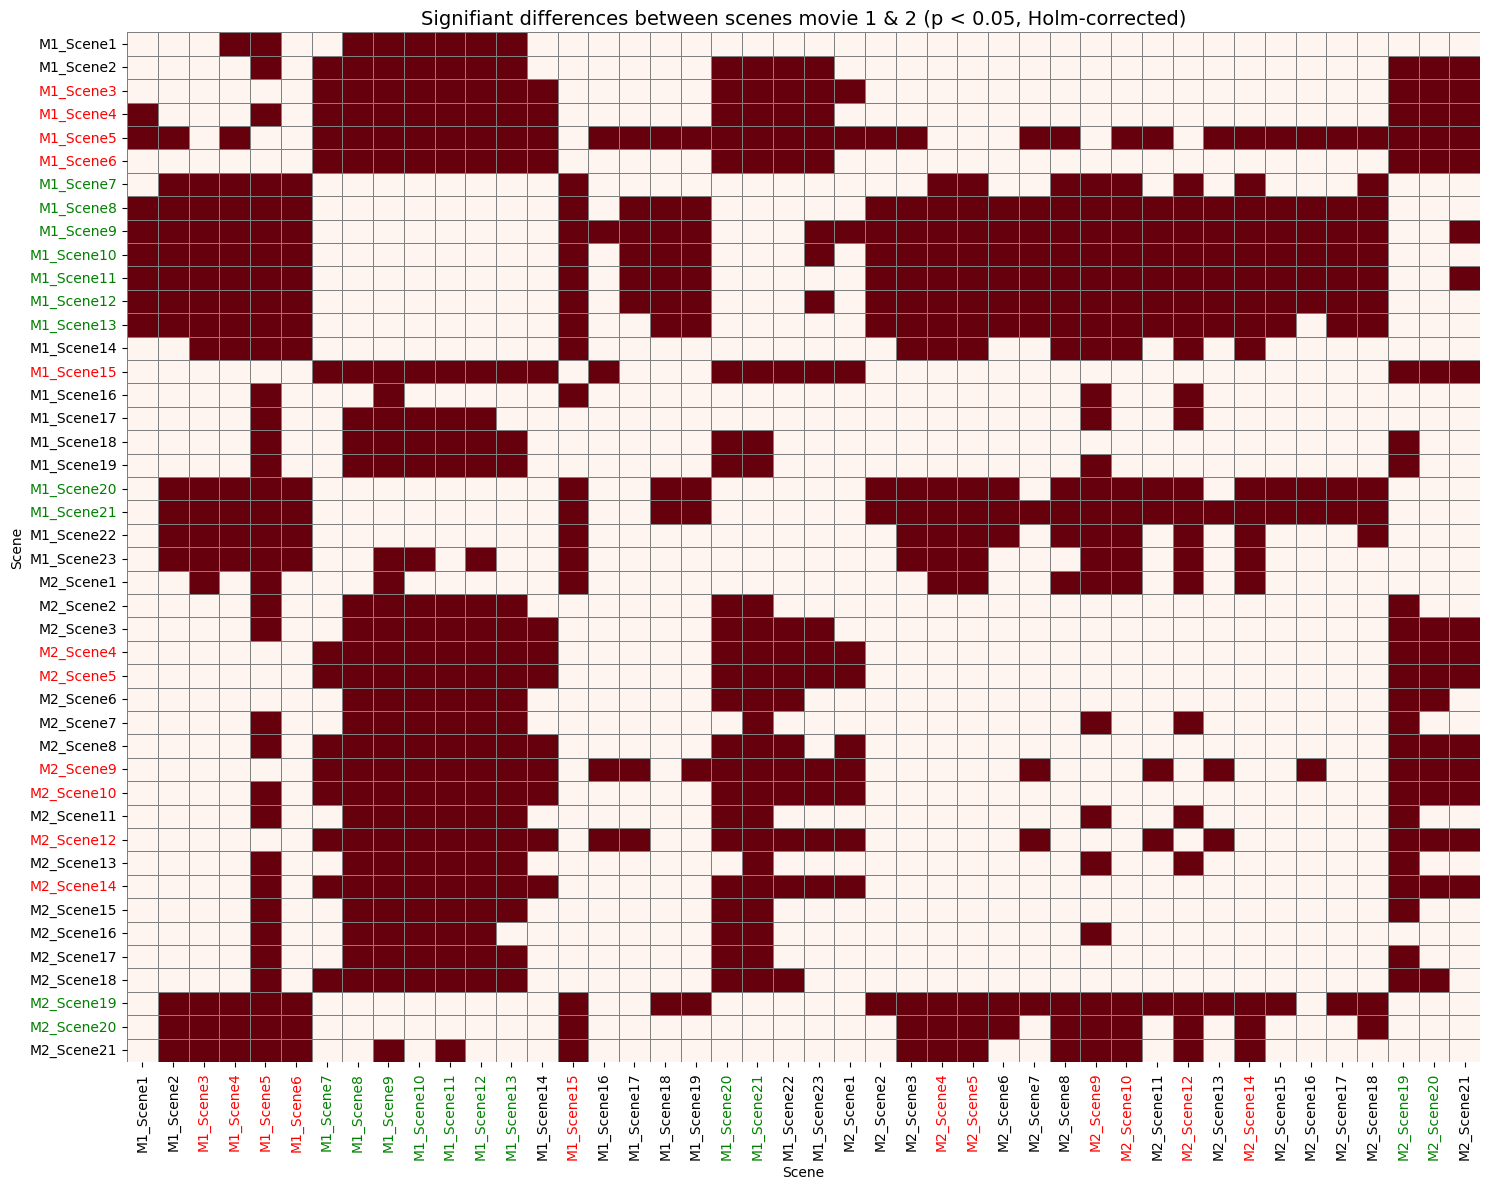

In [135]:
# Mask for top triangle
#mask = np.triu(np.ones_like(sig_matrix, dtype=bool), k=1)


plt.figure(figsize=(15, 12))
sns.heatmap(sig_matrix, cmap="Reds", cbar=False, linewidths=0.5, linecolor='gray') # optional: mask = mask
plt.title("Significant differences between scenes movie 1 & 2 (p < 0.05, Holm-corrected)", fontsize=14)
plt.xlabel("Scene")
plt.ylabel("Scene")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# get objects of axes (ticks)
ticks_objs = plt.gca().get_xticklabels()  # X-axis-Ticks
ticks_objs_y = plt.gca().get_yticklabels()  # Y-axis-Ticks

# Define scene index positions 
TIR_scenes = [6, 7, 8, 9, 10, 11, 12, 19, 20, 41, 42]  # TIR scenes -> green
TR_scenes = [2, 3, 4, 5, 14, 26, 27, 31, 32, 34, 36]  # TR Szenen -> red

# Set green for TIR Scenes
for i in TIR_scenes:
    ticks_objs[i].set_color('green')
    ticks_objs_y[i].set_color('green')

# Set red for TR Szenen
for j in TR_scenes:
    ticks_objs[j].set_color('red')
    ticks_objs_y[j].set_color('red')


plt.tight_layout()

#Save plot 
plt.savefig(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1\Figures\Significant_differences_between_scenes_movie_1_2.png", dpi=300, bbox_inches="tight")

plt.show()

#### 1.4. Repeated-Measures ANOVA (Scaled Scores) --> used in paper!

In [157]:
# 1. Scale Scores
df_filtered_movie_1_2 = final_df_movie_1_2[new_scene_labels]
df_scaled_movie_1_2 = df_filtered_movie_1_2.apply(lambda row: 10 * (row - row.min()) / (row.max() - row.min()) if row.max() != row.min() else 0, axis=1)
df_scaled_movie_1_2['Subject_ID'] = final_df_movie_1_2['Subject_ID']

# 2. Long-Format
long_df_movie_1_2_scaled = pd.melt(df_scaled_movie_1_2,
                  id_vars='Subject_ID',
                  value_vars=new_scene_labels,
                  var_name='Scene',
                  value_name='Rating')

# 3. Repeated Measures ANOVA
aov = pg.rm_anova(dv='Rating', within='Scene', subject='Subject_ID', data=long_df_movie_1_2_scaled, detailed=True)
print("ANOVA:\n", aov)

# 5. Post-hoc with Holm corection
posthocs = pg.pairwise_tests(dv='Rating',
                              within='Scene',
                              subject='Subject_ID',
                              padjust='holm',
                              data=long_df_movie_1_2_scaled)

# 6. Only show significant results
significant_results_movie_1_2_scaled = posthocs[posthocs['p-corr'] < 0.05][['A', 'B', 'p-corr']]

# 7. Save as csv
save_path = r'C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1\Significance_test_scene_comparisons\significant_scene_comparisons_movie_1_and_2_scaled_values.csv'
significant_results_movie_1_2_scaled.to_csv(save_path, index=False)

print("\n saved csv as: significant_scene_comparisons_movie_1_and_2_scaled_values.csv")

print("\n Significant Scene Comparisons Scaled Values (p-corr < 0.05):")
print(significant_results_movie_1_2_scaled)

ANOVA:
   Source           SS    DF         MS          F          p-unc  \
0  Scene  4132.362026    43  96.101442  23.507948  5.398258e-141   
1  Error  7031.429574  1720   4.088040        NaN            NaN   

      p-GG-corr       ng2       eps sphericity       W-spher   p-spher  
0  1.405078e-48  0.311281  0.332226      False  2.551359e-20  0.000096  
1           NaN       NaN       NaN        NaN           NaN       NaN  

 saved csv as: significant_scene_comparisons_movie_1_and_2_scaled_values.csv

 Significant Scene Comparisons Scaled Values (p-corr < 0.05):
              A           B    p-corr
0     M1_Scene1  M1_Scene10  0.006323
1     M1_Scene1  M1_Scene11  0.027080
2     M1_Scene1  M1_Scene12  0.012417
17    M1_Scene1   M1_Scene5  0.000002
20    M1_Scene1   M1_Scene8  0.004672
..          ...         ...       ...
920  M2_Scene21   M2_Scene5  0.000279
921  M2_Scene21   M2_Scene6  0.031181
923  M2_Scene21   M2_Scene8  0.001299
924  M2_Scene21   M2_Scene9  0.000012
944   M2_

#### 1.5. Visualize in a matrix (Scaled Scores) --> used in paper

In [159]:
# All scenes
scenes = (long_df_movie_1_2_scaled['Scene'].unique())

# Empty matrix with scenes as rows and columns
sig_matrix = pd.DataFrame(0, index=scenes, columns=scenes)

# Put 1 if significantly different
for _, row in significant_results_movie_1_2_scaled.iterrows():
    scene_a = row['A']
    scene_b = row['B']
    sig_matrix.loc[scene_a, scene_b] = 1
    sig_matrix.loc[scene_b, scene_a] = 1  # Symmetrisch, da A vs B = B vs A

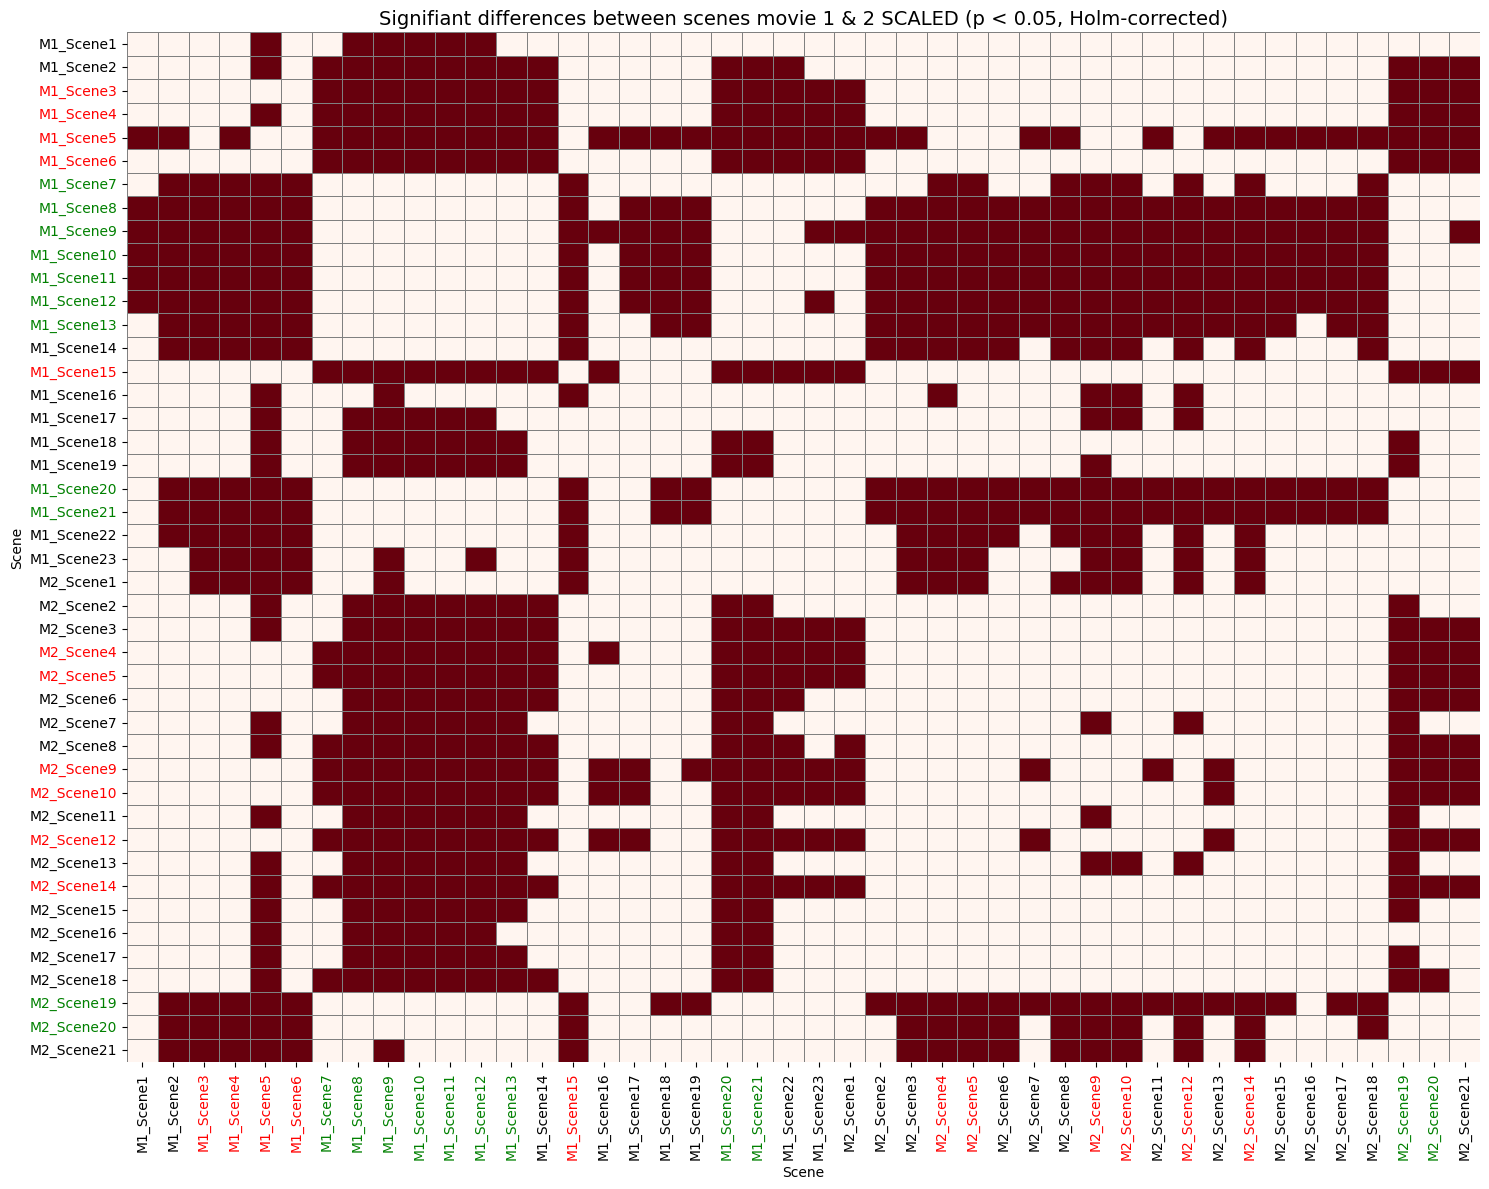

In [161]:
# Mask for top triangle
#mask = np.triu(np.ones_like(sig_matrix, dtype=bool), k=1)


plt.figure(figsize=(15, 12))
sns.heatmap(sig_matrix, cmap="Reds", cbar=False, linewidths=0.5, linecolor='gray') # optional: mask = mask
plt.title("Significant differences between scenes movie 1 & 2 SCALED (p < 0.05, Holm-corrected)", fontsize=14)
plt.xlabel("Scene")
plt.ylabel("Scene")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# get objects of axes (ticks)
ticks_objs = plt.gca().get_xticklabels()  # X-axis-Ticks
ticks_objs_y = plt.gca().get_yticklabels()  # Y-axis-Ticks

# Define scene index positions 
TIR_scenes = [6, 7, 8, 9, 10, 11, 12, 19, 20, 41, 42]  # TIR scenes -> green
TR_scenes = [2, 3, 4, 5, 14, 26, 27, 31, 32, 34, 36]  # TR scenes -> red

# Set green for TIR Scenes
for i in TIR_scenes:
    ticks_objs[i].set_color('green')
    ticks_objs_y[i].set_color('green')

# Set red for TR Szenen
for j in TR_scenes:
    ticks_objs[j].set_color('red')
    ticks_objs_y[j].set_color('red')


plt.tight_layout()

#Save plot 
plt.savefig(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1\Figures\Significant_differences_between_scenes_movie_1_2_scaled.png", dpi=300, bbox_inches="tight")

plt.show()

### 2. Movies 3 & 4

#### 2.1. Create Dataframe (same way as in script named "Define Trait (ir)-relevant Scenes")

*Navigate into the right folder*

In [163]:
print(os.getcwd())
os.chdir(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2")
print(os.getcwd())

C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1
C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2


In [165]:
# Folder with CSV files (Pavlovia Output)
data_folder = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2"

# List for collected data 
all_data = []

# Go through all csv files in the folder
for file in os.listdir(data_folder):
    if file.endswith(".csv"):  # make sure that it is a csv file
        file_path = os.path.join(data_folder, file)
        
        # Read csv file
        df = pd.read_csv(file_path)

        # Extract Subject ID from filename
        subject_id = file.split("_")[0]  # First part of the filename is the Subject ID

        # Compute neuroticism movie scene ratings
        variable_movie_scenes = df["Movie_scenes"].dropna().reset_index(drop=True)
        frustrated_clean = df["Rating_Question_answer_This scene made me feel frustrated"].dropna().reset_index(drop=True)
        dissatisfied_clean = df["Rating_Question_answer_This scene made me feel dissatisfied with myself"].dropna().reset_index(drop=True)
        tense_clean = df["Rating_Question_answer_This scene made me feel tense"].dropna().reset_index(drop=True)
        confident_clean = df["Rating_Question_answer_This scene made me feel confident in myself and my abilities"].dropna().reset_index(drop=True)
        safe_clean = df["Rating_Question_answer_This scene made me feel safe and secure"].dropna().reset_index(drop=True)
        happy_clean = df["Rating_Question_answer_This scene made me feel happy"].dropna().reset_index(drop=True)

        # Combine variables
        complete_movie_scene_ratings = pd.concat(
            [variable_movie_scenes, frustrated_clean, dissatisfied_clean, tense_clean, confident_clean, safe_clean, happy_clean], 
            axis=1
        )

        # Reverse coding
        reverse_map = {1.0: 5.0, 2.0: 4.0, 3.0: 3.0, 4.0: 2.0, 5.0: 1.0}
        reverse_columns = ["Rating_Question_answer_This scene made me feel confident in myself and my abilities", 
                           "Rating_Question_answer_This scene made me feel safe and secure", 
                           "Rating_Question_answer_This scene made me feel happy"]

        for col in reverse_columns:
            complete_movie_scene_ratings[col + "_reversed"] = complete_movie_scene_ratings[col].replace(reverse_map)

        # Compute sum score
        sum_columns = ["Rating_Question_answer_This scene made me feel frustrated",
                       "Rating_Question_answer_This scene made me feel dissatisfied with myself",
                       "Rating_Question_answer_This scene made me feel tense"] + [col + "_reversed" for col in reverse_columns]

        complete_movie_scene_ratings["Sum_N_score_scene"] = complete_movie_scene_ratings[sum_columns].sum(axis=1)

        # Save individual file with movie scene ratings per subject
        # output_folder = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Individual_movie_scene_ratings"
        # file_path_individual_scene_ratings = os.path.join(output_folder, f"complete_movie_scene_ratings_subject_{subject_id}.csv")
        # complete_movie_scene_ratings.to_csv(file_path_individual_scene_ratings, index=False)

        # Compute the neuroticism score from the NEO_FFI_items
        
        map_normally_coded_items = {"SD": 0, "D": 1, "N": 2, "A": 3, "SA": 4} # Items 6, 11, 21, 26, 36, 41, 51, 56
        map_reverse_coded_items = {"SD": 4, "D": 3, "N": 2, "A": 1, "SA": 0} # Items 1, 16, 31, 46

        normally_coded_items = ["Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.6_I often feel inferior to others.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.11_When I'm under a great deal of stress, sometimes I feel like I am going to pieces.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.21_I often feel tense and jittery.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.26_Sometimes I feel completely worthless.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.36_I often get angry at the way people treat me.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.41_Too often when things go wrong, I get discouraged and feel like giving up.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.51_I often feel helpless and want someone else to solve my problems.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.56_At times I have been so ashamed that I just wanted to hide."]
        reverse_coded_items = ["Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.1_I am not a worrier.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.16_I rarely feel lonely or blue.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.31_I rarely feel fearful or anxious.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.46_I am seldom sad or depressed."]

        def recode_value(value, recode_map):
            return recode_map.get(value, None)  # returns none if unknown value

        neuroticism_item_responses = []

        for item in normally_coded_items:
            if item in df.columns:
                recoded_value = recode_value(df[item].iloc[1], map_normally_coded_items)
                if recoded_value is not None:
                    neuroticism_item_responses.append(recoded_value)
                    
        for item in reverse_coded_items:
            if item in df.columns:
                recoded_value = recode_value(df[item].iloc[1], map_reverse_coded_items)
                if recoded_value is not None:
                    neuroticism_item_responses.append(recoded_value)

        sum_N_score_NEO_FFI = sum(neuroticism_item_responses) if neuroticism_item_responses else None  # if values are missing --> none


        
        # Extract demographic data 
        subject_data = {
            "Subject_ID": subject_id,
            "Subject_ID_excel_sheet": df["participant"].iloc[0],
            "User": df["user"].iloc[0],
            "User_ID": df["user_id"].iloc[0],
            "Age": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_age"].iloc[1],
            "Gender": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_gender"].iloc[1],
            "Education": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_highest_level_education"].iloc[1],
            "Years_of_Education": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_years_of_education"].iloc[1],
            "NEO_FFI_N": sum_N_score_NEO_FFI,
            "Occupation": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_occupation"].iloc[1],
            "Attention_Self_Reflection": df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[311]
                if pd.notna(df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[311]) and df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[311] != ""
                else df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[312]            
        }

        # Check whether the subjects wrote something in the textbox
        if "End_of_study_Pavlovia_survey.block_1/Additional Thoughts:" in df.columns:
            thoughts_col = df["End_of_study_Pavlovia_survey.block_1/Additional Thoughts:"]

            if len(thoughts_col) > 312:
              subject_data["Additional_Thoughts"] = thoughts_col.iloc[311] \
                if pd.notna(thoughts_col.iloc[311]) and thoughts_col.iloc[311] != "" \
                else thoughts_col.iloc[312]
            elif len(thoughts_col) > 311:
             subject_data["Additional_Thoughts"] = thoughts_col.iloc[311]
            else:
             subject_data["Additional_Thoughts"] = None  # fallback for short data

        # Save movie scene sum scores as collumns
        for index, row in complete_movie_scene_ratings.iterrows():
            scene_name = row["Movie_scenes"]
            subject_data[scene_name] = row["Sum_N_score_scene"]

        # Save subject data in list
        all_data.append(subject_data)

# Save complete dataset as csv file
final_df_movie_3_4 = pd.DataFrame(all_data)
# final_file_path = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Combined_data\All_subjects_movie_scenes_group_2_combined.csv"
# final_df_movie_3_4.to_csv(final_file_path, index=False)

# print("Data saved successfully")

#### 2.2. Repeated Measures ANOVA (Raw Scores) --> not used in paper!

In [167]:
import pandas as pd
import pingouin as pg

# 1. Relevant Scene Collumns
scene_cols = [col for col in final_df_movie_3_4.columns if col.startswith("Scenes_Movie_")]

# 2. Rename the Scenes
new_scene_labels =  ["M3_Scene1", "M3_Scene2", "M3_Scene3", "M3_Scene4", "M3_Scene5", "M3_Scene6", "M3_Scene7", "M3_Scene8", "M3_Scene9",  "M3_Scene10", "M3_Scene11", "M3_Scene12", "M3_Scene13", "M3_Scene14", "M3_Scene15", "M3_Scene16", "M3_Scene17", "M3_Scene18", "M3_Scene19", "M3_Scene20", "M3_Scene21", "M3_Scene22", "M4_Scene1", "M4_Scene2", "M4_Scene3", "M4_Scene4", "M4_Scene5","M4_Scene6", "M4_Scene7", "M4_Scene8", "M4_Scene9",  "M4_Scene10", "M4_Scene11", "M4_Scene12", "M4_Scene13", "M4_Scene14", "M4_Scene15", "M4_Scene16", "M4_Scene17", "M4_Scene18", "M4_Scene19", "M4_Scene20", "M4_Scene21", "M4_Scene22"]
rename_dict = dict(zip(scene_cols, new_scene_labels))
final_df_movie_3_4 = final_df_movie_3_4.rename(columns=rename_dict)

# 3. Long-Format
long_df_movie_3_4 = pd.melt(final_df_movie_3_4,
                  id_vars='Subject_ID',
                  value_vars=new_scene_labels,
                  var_name='Scene',
                  value_name='Rating')

# 4. Repeated Measures ANOVA
aov = pg.rm_anova(dv='Rating', within='Scene', subject='Subject_ID', data=long_df_movie_3_4, detailed=True)
print("ANOVA:\n", aov)

# 5. Post-hoc with Holm corection
posthocs = pg.pairwise_tests(dv='Rating',
                              within='Scene',
                              subject='Subject_ID',
                              padjust='holm',
                              data=long_df_movie_3_4)

# 6. Only show significant results
significant_results_movie_3_4 = posthocs[posthocs['p-corr'] < 0.05][['A', 'B', 'p-corr']]

# 7. Save as csv
save_path = r'C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Significance_test_scene_comparisons\significant_scene_comparisons_movie_3_and_4.csv'
significant_results_movie_3_4.to_csv(save_path, index=False)

print("\n Saved csv. as: significant_scene_comparisons_movie_3_and_4.csv")

print("\n Significant Scene Comparisons (p-corr < 0.05):")
print(significant_results_movie_3_4)

ANOVA:
   Source            SS    DF          MS          F          p-unc  \
0  Scene  15543.036364    43  361.465962  36.851308  1.293873e-215   
1  Error  18558.190909  1892    9.808769        NaN            NaN   

      p-GG-corr       ng2       eps sphericity       W-spher       p-spher  
0  2.310061e-53  0.401732  0.237986      False  2.157125e-27  4.252488e-55  
1           NaN       NaN       NaN        NaN           NaN           NaN  

 Saved csv. as: significant_scene_comparisons_movie_3_and_4.csv

 Significant Scene Comparisons (p-corr < 0.05):
             A           B        p-corr
5    M3_Scene1  M3_Scene15  9.070557e-04
6    M3_Scene1  M3_Scene16  4.940842e-04
7    M3_Scene1  M3_Scene17  3.290912e-05
8    M3_Scene1  M3_Scene18  5.153100e-05
9    M3_Scene1  M3_Scene19  3.480002e-08
..         ...         ...           ...
926  M4_Scene3   M4_Scene5  1.555840e-05
927  M4_Scene3   M4_Scene6  8.470649e-06
930  M4_Scene3   M4_Scene9  1.426442e-02
937  M4_Scene5   M4_Scene7

#### 2.3. Visualize in a matrix (Raw Scores) --> not used in paper!

In [172]:
# All scenes
scenes = (long_df_movie_3_4['Scene'].unique())

# Empty matrix with scenes as rows and columns
sig_matrix = pd.DataFrame(0, index=scenes, columns=scenes)

# Put 1 if significantly different
for _, row in significant_results_movie_3_4.iterrows():
    scene_a = row['A']
    scene_b = row['B']
    sig_matrix.loc[scene_a, scene_b] = 1
    sig_matrix.loc[scene_b, scene_a] = 1  # symmetric, because A vs B = B vs A

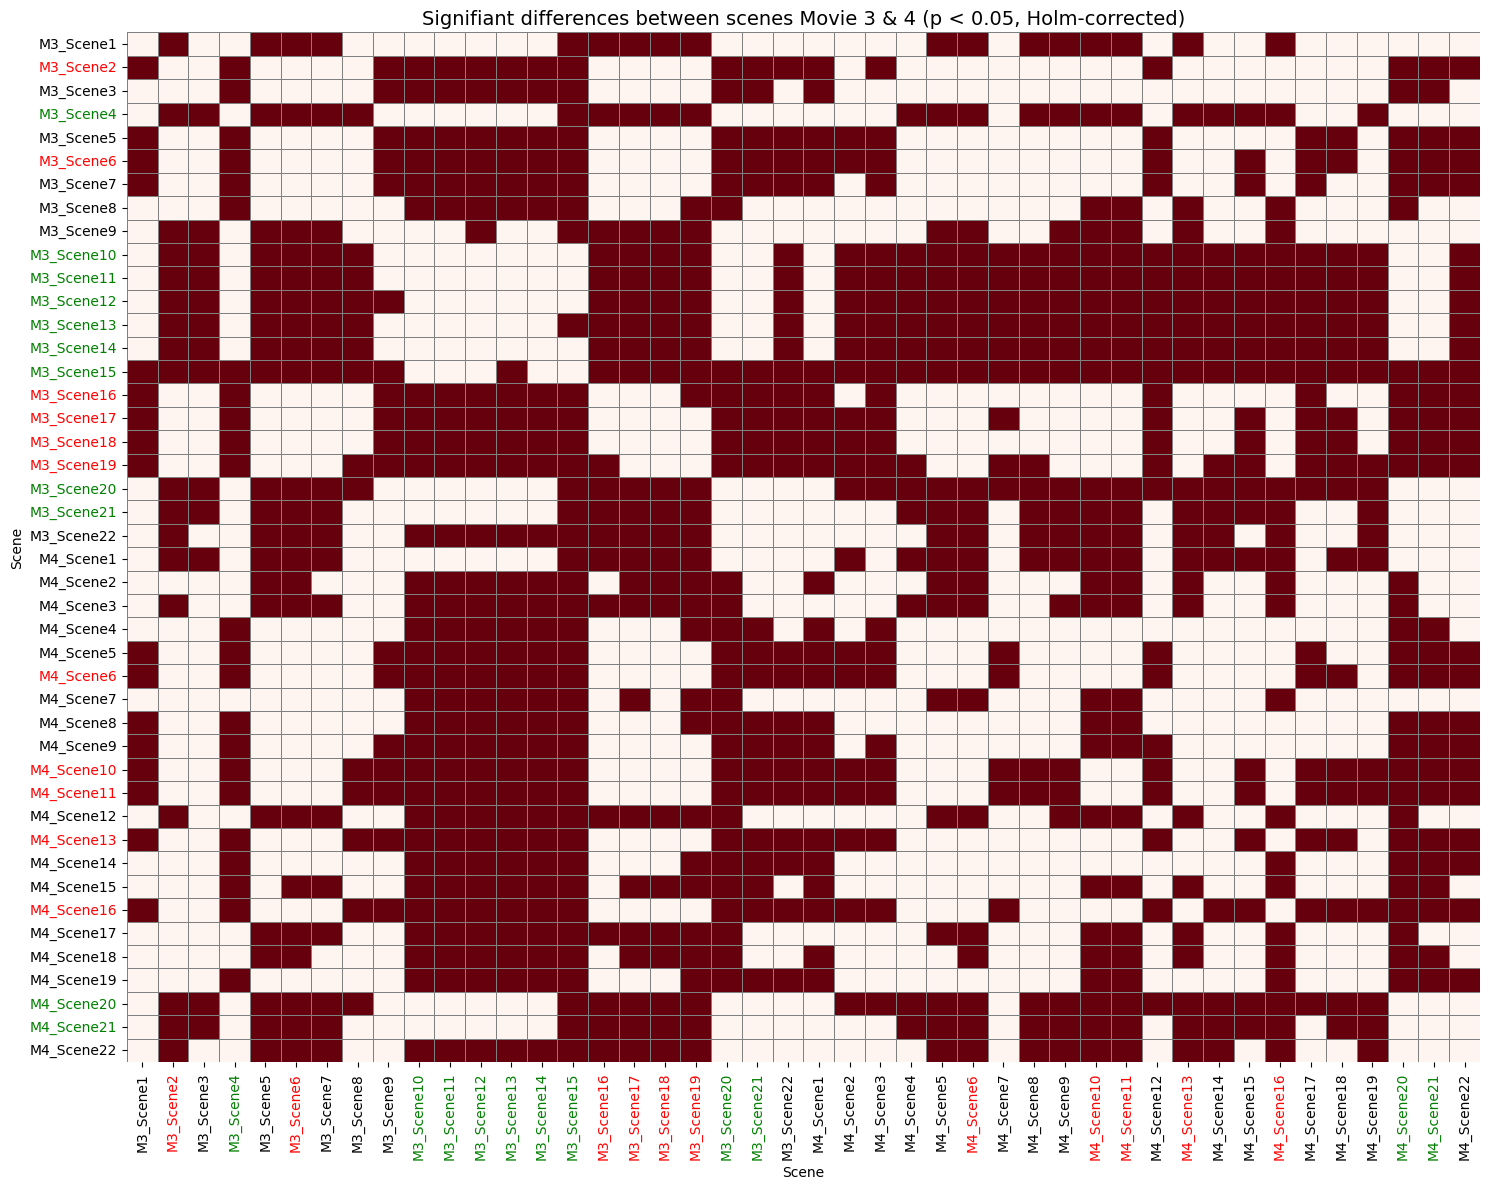

In [174]:
plt.figure(figsize=(15, 12))
sns.heatmap(sig_matrix, cmap="Reds", cbar=False, linewidths=0.5, linecolor='gray') # optional: mask = mask
plt.title("Significant differences between scenes Movie 3 & 4 (p < 0.05, Holm-corrected)", fontsize=14)
plt.xlabel("Scene")
plt.ylabel("Scene")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# get objects of axes (ticks)
ticks_objs = plt.gca().get_xticklabels()  # X-axis-Ticks
ticks_objs_y = plt.gca().get_yticklabels()  # Y-axis-Ticks

# Define Scene index positions 
TIR_scenes = [3,9,10,11,12,13,14,19,20,41,42]  # TIR scenes -> green
TR_scenes = [1,5,15,16,17,18,27,31,32,34,37]  # TR scenes -> red

# Set green for TIR Scenes
for i in TIR_scenes:
    ticks_objs[i].set_color('green')
    ticks_objs_y[i].set_color('green')

# Set red for TR Szenen
for j in TR_scenes:
    ticks_objs[j].set_color('red')
    ticks_objs_y[j].set_color('red')


plt.tight_layout()

#Save plot 
plt.savefig(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Figures\Significant_differences_between_scenes_movie_3_4.png", dpi=300, bbox_inches="tight")

plt.show()

#### 2.4. Repeated-Measures ANOVA (Scaled Scores) --> used in paper!

In [178]:
# 1. Scale Scores
df_filtered_movie_3_4 = final_df_movie_3_4[new_scene_labels]
df_scaled_movie_3_4 = df_filtered_movie_3_4.apply(lambda row: 10 * (row - row.min()) / (row.max() - row.min()) if row.max() != row.min() else 0, axis=1)
df_scaled_movie_3_4['Subject_ID'] = final_df_movie_3_4['Subject_ID']

# 2. Long-Format
long_df_movie_3_4_scaled = pd.melt(df_scaled_movie_3_4,
                  id_vars='Subject_ID',
                  value_vars=new_scene_labels,
                  var_name='Scene',
                  value_name='Rating')

# 3. Repeated Measures ANOVA
aov = pg.rm_anova(dv='Rating', within='Scene', subject='Subject_ID', data=long_df_movie_3_4_scaled, detailed=True)
print("ANOVA:\n", aov)

# 5. Post-hoc with Holm corection
posthocs = pg.pairwise_tests(dv='Rating',
                              within='Scene',
                              subject='Subject_ID',
                              padjust='holm',
                              data=long_df_movie_3_4_scaled)

# 6. Only show significant results
significant_results_movie_3_4_scaled = posthocs[posthocs['p-corr'] < 0.05][['A', 'B', 'p-corr']]

# 7. Save as csv
save_path = r'C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 1\Significance_test_scene_comparisons\significant_scene_comparisons_movie_3_and_4_scaled_values.csv'
significant_results_movie_3_4_scaled.to_csv(save_path, index=False)

print("\n saved csv as: significant_scene_comparisons_movie_3_and_4_scaled_values.csv")

print("\n Significant Scene Comparisons Scaled Values (p-corr < 0.05):")
print(significant_results_movie_3_4_scaled)

ANOVA:
   Source           SS    DF          MS          F          p-unc  \
0  Scene  6872.745576    43  159.831292  39.346539  8.632923e-228   
1  Error  7685.575735  1892    4.062144        NaN            NaN   

      p-GG-corr      ng2       eps sphericity       W-spher       p-spher  
0  2.191244e-76  0.43556  0.327207      False  4.481388e-23  1.012048e-27  
1           NaN      NaN       NaN        NaN           NaN           NaN  

 saved csv as: significant_scene_comparisons_movie_3_and_4_scaled_values.csv

 Significant Scene Comparisons Scaled Values (p-corr < 0.05):
             A           B        p-corr
5    M3_Scene1  M3_Scene15  2.923880e-03
6    M3_Scene1  M3_Scene16  9.654498e-04
7    M3_Scene1  M3_Scene17  1.334464e-05
8    M3_Scene1  M3_Scene18  7.961875e-06
9    M3_Scene1  M3_Scene19  6.829145e-09
..         ...         ...           ...
926  M4_Scene3   M4_Scene5  1.678995e-05
927  M4_Scene3   M4_Scene6  5.705184e-05
930  M4_Scene3   M4_Scene9  6.541512e-03
937  

#### 2.5. Visualize in a matrix (Scaled Scores) --> used in paper!

In [181]:
# All scenes
scenes = (long_df_movie_3_4_scaled['Scene'].unique())

# Empty matrix with scenes as rows and columns
sig_matrix = pd.DataFrame(0, index=scenes, columns=scenes)

# Put 1 if significantly different
for _, row in significant_results_movie_3_4_scaled.iterrows():
    scene_a = row['A']
    scene_b = row['B']
    sig_matrix.loc[scene_a, scene_b] = 1
    sig_matrix.loc[scene_b, scene_a] = 1  # Symmetrisch, because A vs B = B vs A

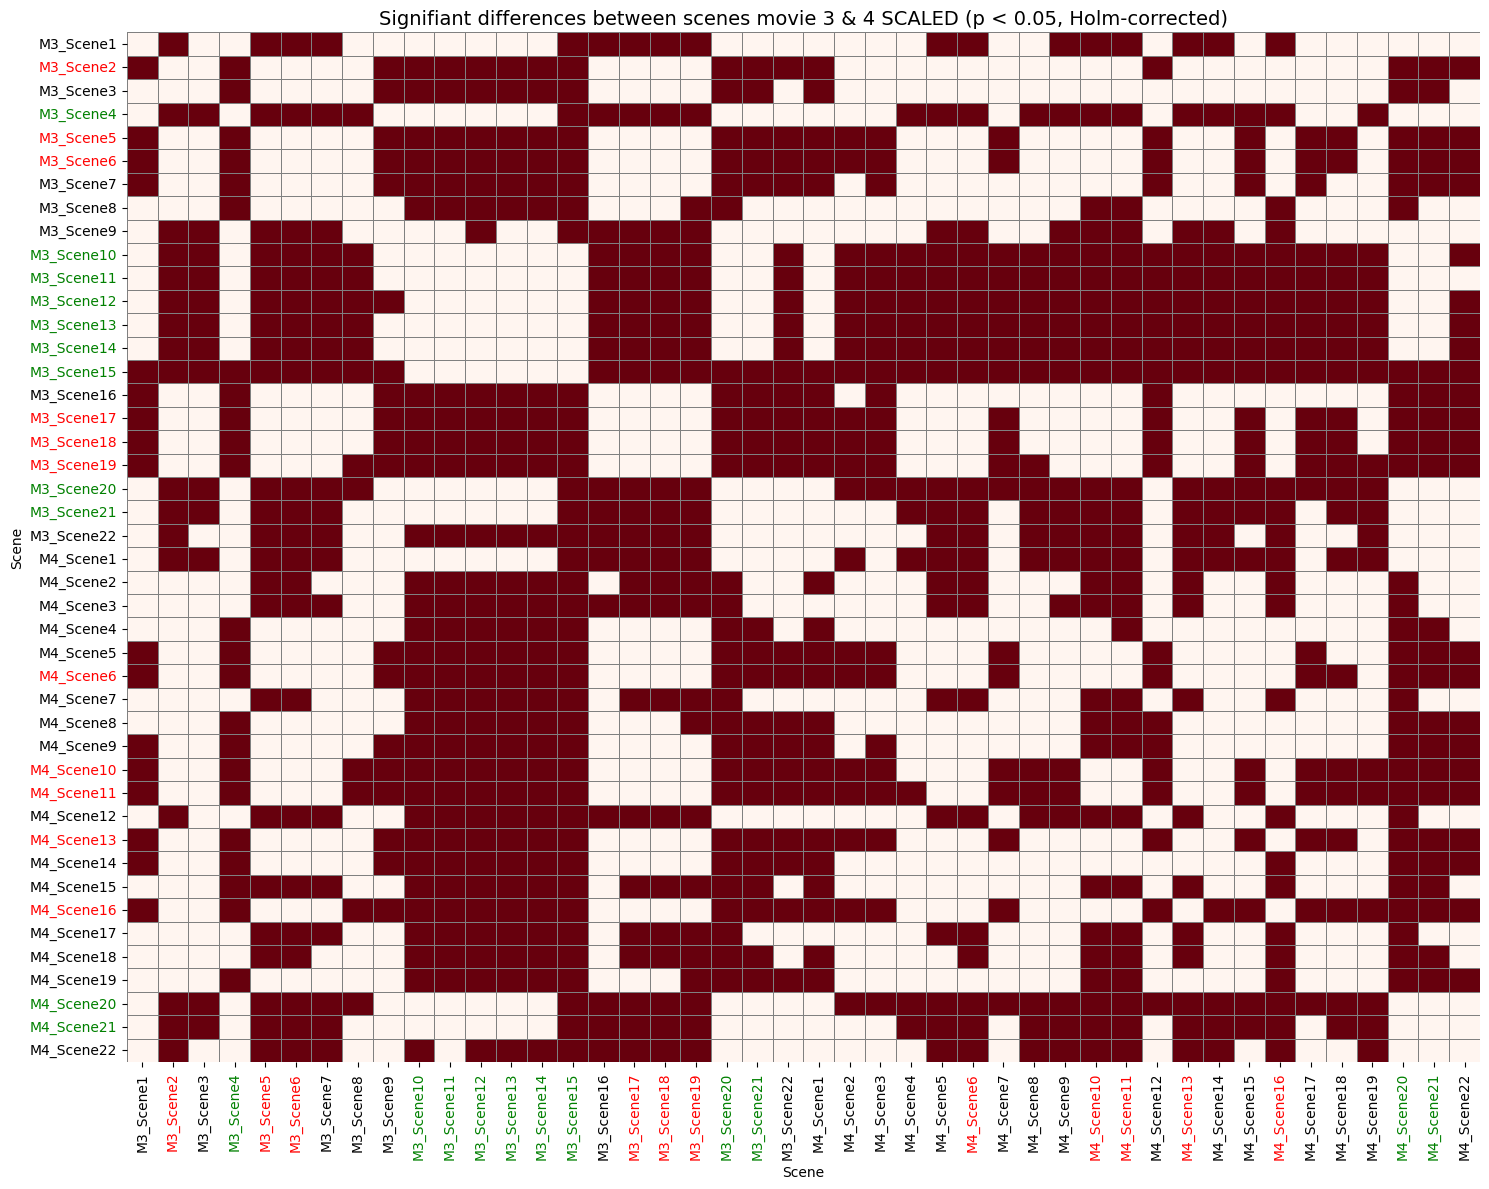

In [183]:
# Mask for top triangle
#mask = np.triu(np.ones_like(sig_matrix, dtype=bool), k=1)


plt.figure(figsize=(15, 12))
sns.heatmap(sig_matrix, cmap="Reds", cbar=False, linewidths=0.5, linecolor='gray') # optional: mask = mask
plt.title("Signifiant differences between scenes movie 3 & 4 SCALED (p < 0.05, Holm-corrected)", fontsize=14)
plt.xlabel("Scene")
plt.ylabel("Scene")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# get objects of axes (ticks)
ticks_objs = plt.gca().get_xticklabels()  # X-axis-Ticks
ticks_objs_y = plt.gca().get_yticklabels()  # Y-axis-Ticks

# Define scene index positions 
TIR_scenes = [3,9,10,11,12,13,14,19,20,41,42]  # TIR scenes -> green
TR_scenes = [1,4,5,16,17,18,27,31,32,34,37]  # TR scenes -> red

# Set green for TIR Scenes
for i in TIR_scenes:
    ticks_objs[i].set_color('green')
    ticks_objs_y[i].set_color('green')

# Set red for TR Szenen
for j in TR_scenes:
    ticks_objs[j].set_color('red')
    ticks_objs_y[j].set_color('red')


plt.tight_layout()

#Save plot 
plt.savefig(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Figures\Significant_differences_between_scenes_movie_3_4_scaled.png", dpi=300, bbox_inches="tight")

plt.show()